Car - mpg modelling demo 

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("car_mpg_dataset.csv")

print("=" * 50)
print("HEAD (first 5 rows)")
print("=" * 50)
print(df.head())

print("\n" + "=" * 50)
print("SHAPE")
print("=" * 50)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n" + "=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("INFO")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

print("\n" + "=" * 50)
print("DESCRIPTIVE STATISTICS (numeric columns)")
print("=" * 50)
print(df.describe())

print("\n" + "=" * 50)
print("UNIQUE VALUES (object / string columns)")
print("=" * 50)
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"\n{col} — {df[col].nunique()} unique values:")
    print(df[col].value_counts().head(10))

print("\n" + "=" * 50)
print("DUPLICATE ROWS")
print("=" * 50)
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n" + "=" * 50)
print("CORRELATION MATRIX")
print("=" * 50)
print(df.select_dtypes(include=np.number).corr().round(2))

HEAD (first 5 rows)
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0        8.0         307.0       130.0  3504.0          12.0   
1  15.0        8.0         350.0       165.0  3693.0          11.5   
2  18.0        8.0         318.0       150.0  3436.0          11.0   
3  16.0        8.0         304.0       150.0  3433.0          12.0   
4  17.0        8.0         302.0       140.0  3449.0          10.5   

   model_year origin                   car_name  Unnamed: 9  Unnamed: 10  \
0        70.0    usa  chevrolet chevelle malibu         NaN          NaN   
1        70.0    usa          buick skylark 320         NaN          NaN   
2        70.0    usa         plymouth satellite         NaN          NaN   
3        70.0    usa              amc rebel sst         NaN          NaN   
4        70.0    usa                ford torino         NaN          NaN   

  Unnamed: 11  
0        TRUE  
1       FALSE  
2         NaN  
3        10.3  
4         NaN  

SHAPE

C:\Users\joann\AppData\Local\Temp\ipykernel_13024\3676493017.py:40: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("car_mpg_dataset.csv")

# ─── Separate Categorical and Continuous Columns ───────────────────────

# Method 1: By dtype
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
continuous_cols  = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("=" * 50)
print(f"CATEGORICAL COLUMNS ({len(categorical_cols)})")
print("=" * 50)
print(categorical_cols)

print("\n" + "=" * 50)
print(f"CONTINUOUS COLUMNS ({len(continuous_cols)})")
print("=" * 50)
print(continuous_cols)

print("\n" + "=" * 50)
print("CATEGORICAL — Unique Value Counts")
print("=" * 50)
for col in categorical_cols:
    print(f"\n {col} — {df[col].nunique()} unique values")
    print(df[col].value_counts())

print("\n" + "=" * 50)
print("CONTINUOUS — Summary Statistics")
print("=" * 50)
print(df[continuous_cols].describe().T)  # .T = transposed for readability

# ─── Method 2: Catch "hidden" categoricals ────────────────────────────
# Numeric columns with very few unique values are likely categorical
# (e.g., cylinders: 4/6/8, origin: 1/2/3)
print("\n" + "=" * 50)
print("NUMERIC COLUMNS WITH FEW UNIQUE VALUES (possible categoricals)")
print("=" * 50)
threshold = 10  # tweak this as needed
for col in continuous_cols:
    n_unique = df[col].nunique()
    if n_unique <= threshold:
        print(f"   {col}: {n_unique} unique values → {sorted(df[col].dropna().unique())}")

CATEGORICAL COLUMNS (3)
['origin', 'car_name', 'Unnamed: 11']

CONTINUOUS COLUMNS (9)
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'Unnamed: 9', 'Unnamed: 10']

CATEGORICAL — Unique Value Counts

 origin — 1 unique values
origin
usa    10
Name: count, dtype: int64

 car_name — 10 unique values
car_name
chevrolet chevelle malibu    1
buick skylark 320            1
plymouth satellite           1
amc rebel sst                1
ford torino                  1
ford galaxie 500             1
chevrolet impala             1
plymouth fury iii            1
pontiac catalina             1
amc ambassador dpl           1
Name: count, dtype: int64

 Unnamed: 11 — 3 unique values
Unnamed: 11
TRUE     1
FALSE    1
10.3     1
Name: count, dtype: int64

CONTINUOUS — Summary Statistics
              count         mean         std     min      25%     50%  \
mpg            10.0    15.600000    1.577621    14.0    14.25    15.0   
cylinders      10.0     8.000000

C:\Users\joann\AppData\Local\Temp\ipykernel_13024\740486939.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [9]:
# Cast hidden categoricals after reviewing Method 2 output
df["cylinders"] = df["cylinders"].astype("category")
df["origin"]    = df["origin"].astype("category")

Continuous columns : []
Categorical columns: ['origin', 'car_name', 'mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']


C:\Users\joann\AppData\Local\Temp\ipykernel_13024\1578786118.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
C:\Users\joann\AppData\Local\Temp\ipykernel_13024\1578786118.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=value_counts.index,


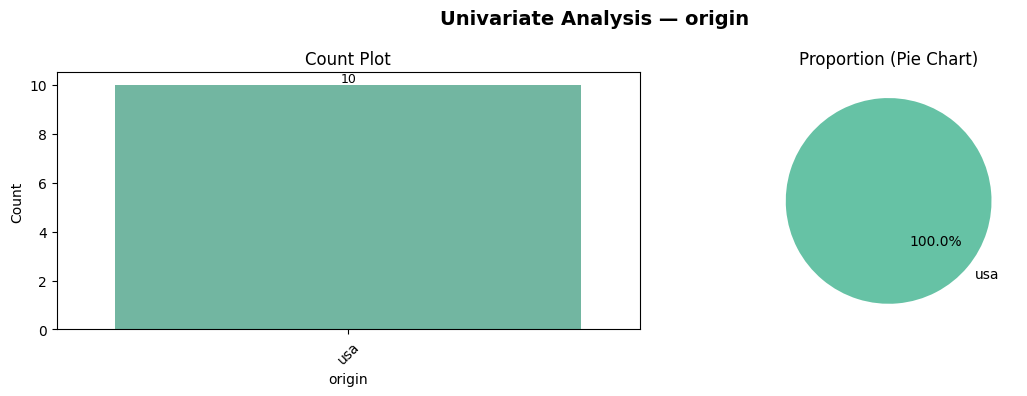

C:\Users\joann\AppData\Local\Temp\ipykernel_13024\1578786118.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=value_counts.index,



 origin
   Unique values : 1
   Most frequent : usa  (10 times)
   Missing       : 5 (33.3%)

origin
usa    10
--------------------------------------------------


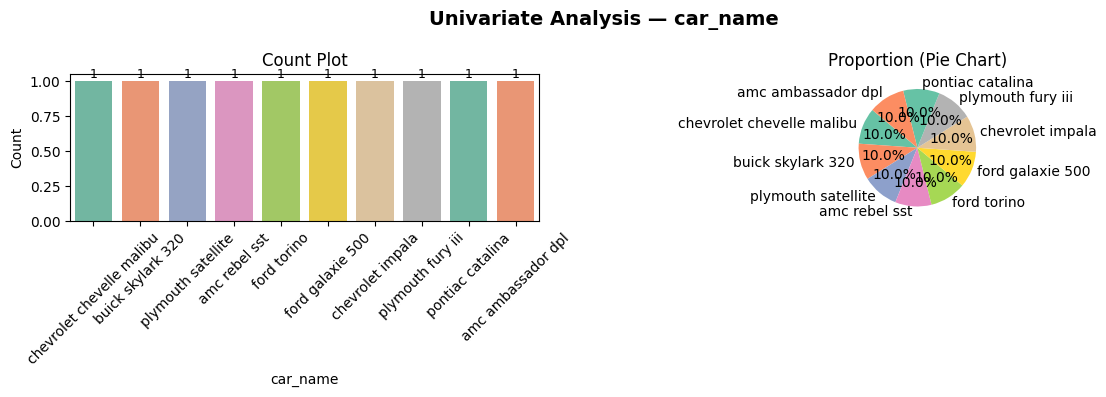


 car_name
   Unique values : 10
   Most frequent : chevrolet chevelle malibu  (1 times)
   Missing       : 5 (33.3%)

car_name
chevrolet chevelle malibu    1
buick skylark 320            1
plymouth satellite           1
amc rebel sst                1
ford torino                  1
ford galaxie 500             1
chevrolet impala             1
plymouth fury iii            1
pontiac catalina             1
amc ambassador dpl           1
--------------------------------------------------


C:\Users\joann\AppData\Local\Temp\ipykernel_13024\1578786118.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=value_counts.index,


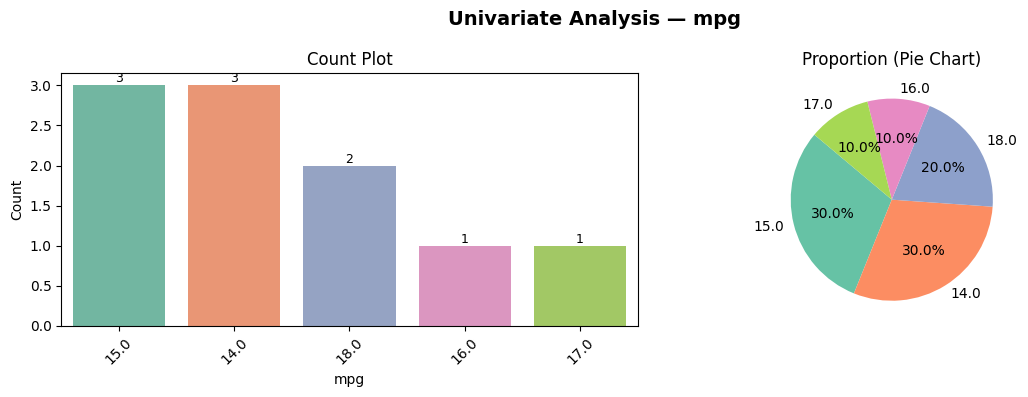


 mpg
   Unique values : 5
   Most frequent : 15.0  (3 times)
   Missing       : 5 (33.3%)

mpg
15.0    3
14.0    3
18.0    2
16.0    1
17.0    1
--------------------------------------------------


C:\Users\joann\AppData\Local\Temp\ipykernel_13024\1578786118.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=value_counts.index,


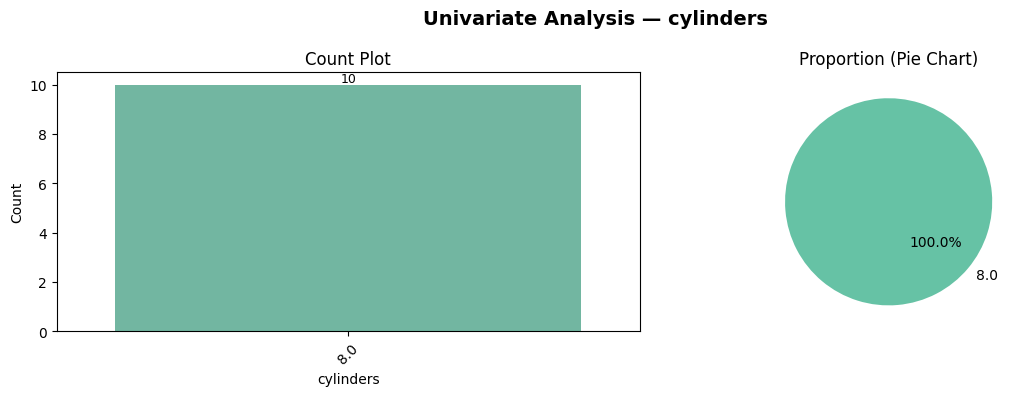


 cylinders
   Unique values : 1
   Most frequent : 8.0  (10 times)
   Missing       : 5 (33.3%)

cylinders
8.0    10
--------------------------------------------------


C:\Users\joann\AppData\Local\Temp\ipykernel_13024\1578786118.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=value_counts.index,


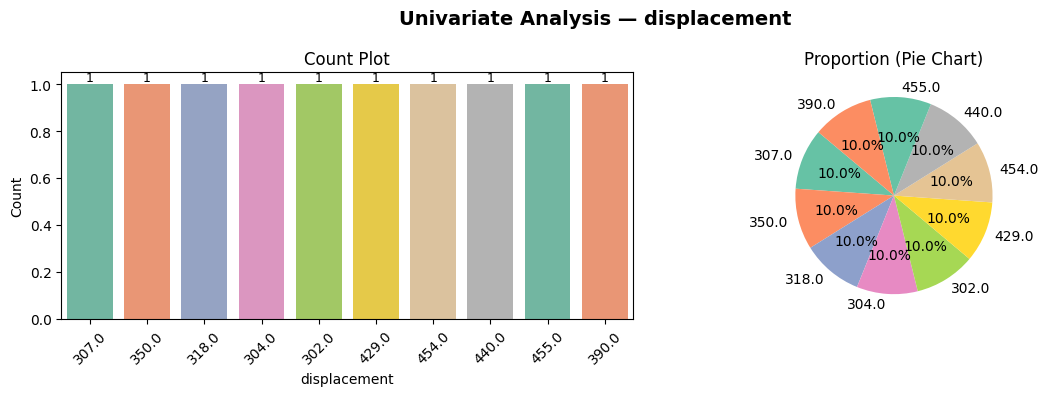


 displacement
   Unique values : 10
   Most frequent : 307.0  (1 times)
   Missing       : 5 (33.3%)

displacement
307.0    1
350.0    1
318.0    1
304.0    1
302.0    1
429.0    1
454.0    1
440.0    1
455.0    1
390.0    1
--------------------------------------------------


C:\Users\joann\AppData\Local\Temp\ipykernel_13024\1578786118.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=value_counts.index,


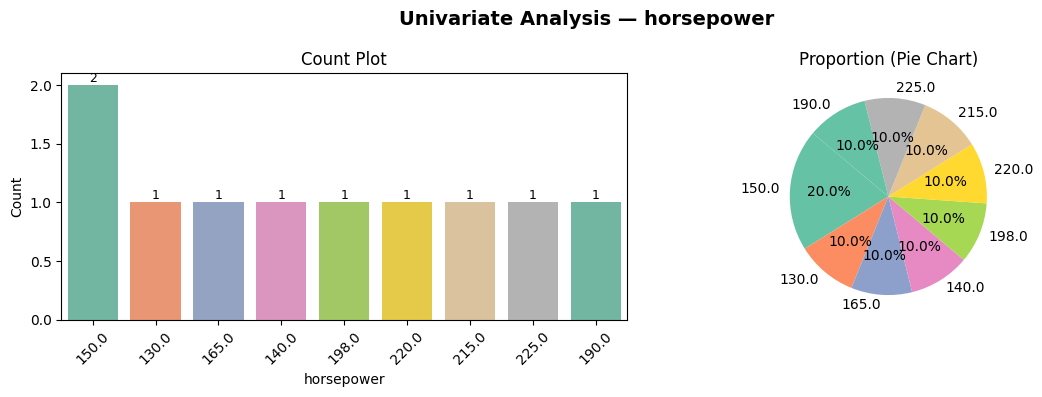


 horsepower
   Unique values : 9
   Most frequent : 150.0  (2 times)
   Missing       : 5 (33.3%)

horsepower
150.0    2
130.0    1
165.0    1
140.0    1
198.0    1
220.0    1
215.0    1
225.0    1
190.0    1
--------------------------------------------------


C:\Users\joann\AppData\Local\Temp\ipykernel_13024\1578786118.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=value_counts.index,


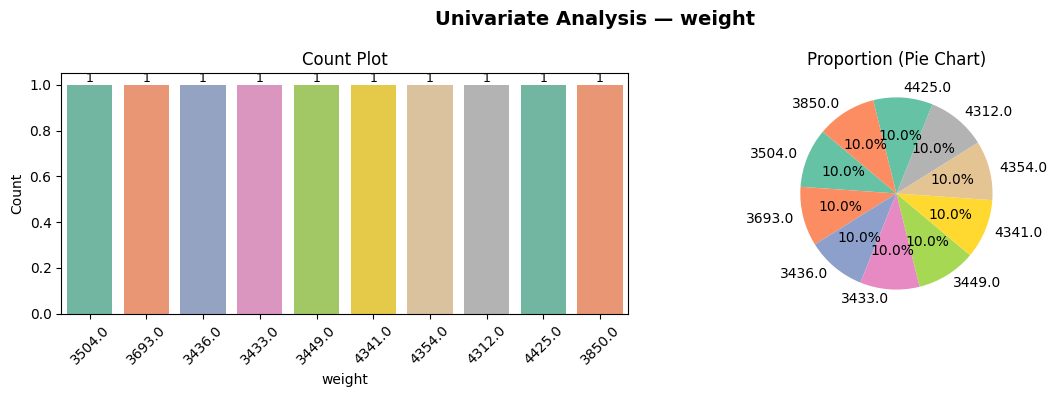


 weight
   Unique values : 10
   Most frequent : 3504.0  (1 times)
   Missing       : 5 (33.3%)

weight
3504.0    1
3693.0    1
3436.0    1
3433.0    1
3449.0    1
4341.0    1
4354.0    1
4312.0    1
4425.0    1
3850.0    1
--------------------------------------------------


C:\Users\joann\AppData\Local\Temp\ipykernel_13024\1578786118.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=value_counts.index,


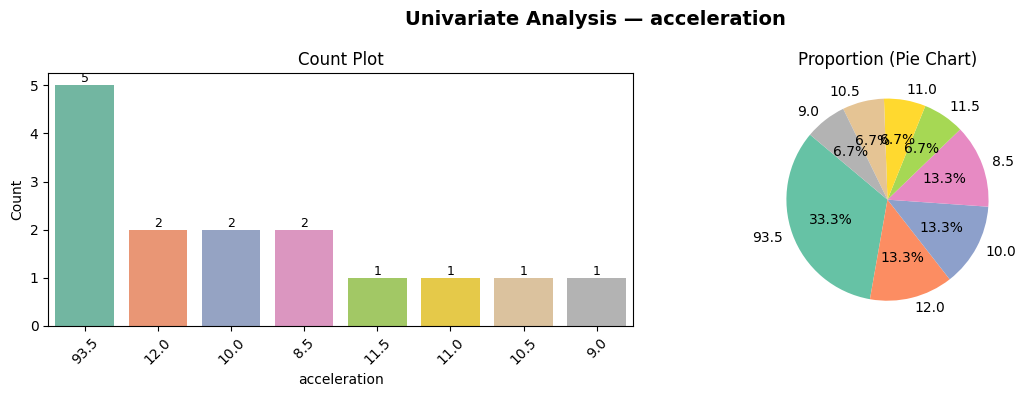


 acceleration
   Unique values : 8
   Most frequent : 93.5  (5 times)
   Missing       : 0 (0.0%)

acceleration
93.5    5
12.0    2
10.0    2
8.5     2
11.5    1
11.0    1
10.5    1
9.0     1
--------------------------------------------------


C:\Users\joann\AppData\Local\Temp\ipykernel_13024\1578786118.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=value_counts.index,


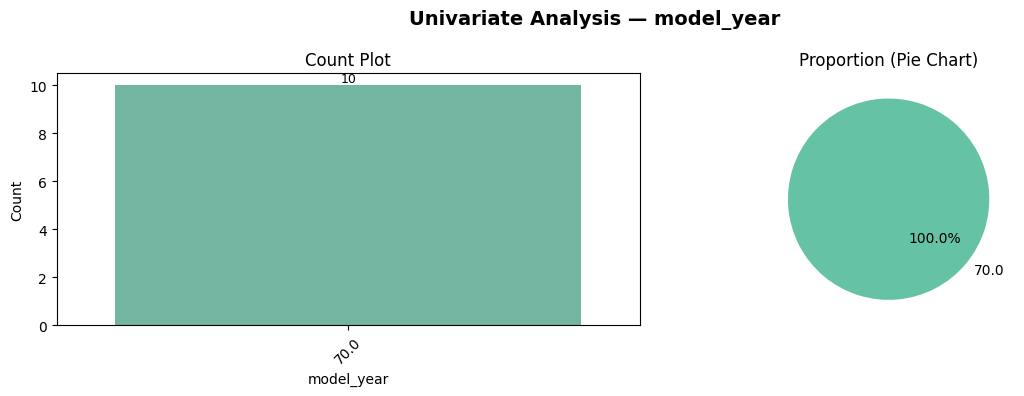


 model_year
   Unique values : 1
   Most frequent : 70.0  (10 times)
   Missing       : 5 (33.3%)

model_year
70.0    10
--------------------------------------------------


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("car_mpg_dataset.csv")

# ─── Auto-detect column types ─────────────────────────────────────────
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
continuous_cols  = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove unnamed/junk columns
continuous_cols  = [c for c in continuous_cols  if "Unnamed" not in c]
categorical_cols = [c for c in categorical_cols if "Unnamed" not in c]

# Catch hidden categoricals (numeric but few unique values)
hidden_cats = [c for c in continuous_cols if df[c].nunique() <= 10]
continuous_cols  = [c for c in continuous_cols  if c not in hidden_cats]
categorical_cols = categorical_cols + hidden_cats

print("Continuous columns :", continuous_cols)
print("Categorical columns:", categorical_cols)


# ══════════════════════════════════════════════════════════════════════
# 1. CONTINUOUS — Histogram + KDE + Boxplot (side by side)
# ══════════════════════════════════════════════════════════════════════
for col in continuous_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Univariate Analysis — {col}", fontsize=14, fontweight="bold")

    # --- Histogram + KDE ---
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0], color="steelblue")
    axes[0].set_title("Histogram + KDE")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")

    # --- Boxplot ---
    sns.boxplot(y=df[col].dropna(), ax=axes[1], color="lightcoral")
    axes[1].set_title("Boxplot (outlier check)")
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

    # --- Summary stats ---
    s = df[col].describe()
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    print(f"\n {col}")
    print(f"   Mean={s['mean']:.2f}  Median={df[col].median():.2f}  Std={s['std']:.2f}")
    print(f"   Min={s['min']:.2f}  Max={s['max']:.2f}")
    print(f"   Skewness={skew:.2f}  Kurtosis={kurt:.2f}")
    missing = df[col].isnull().sum()
    print(f"   Missing={missing} ({missing/len(df)*100:.1f}%)")
    print("-" * 50)


# ══════════════════════════════════════════════════════════════════════
# 2. CATEGORICAL — Count plot + Pie chart (side by side)
# ══════════════════════════════════════════════════════════════════════
for col in categorical_cols:
    value_counts = df[col].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Univariate Analysis — {col}", fontsize=14, fontweight="bold")

    # --- Count / Bar plot ---
    sns.countplot(data=df, x=col, order=value_counts.index,
                  palette="Set2", ax=axes[0])
    axes[0].set_title("Count Plot")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=45)

    # Annotate bars with count
    for p in axes[0].patches:
        axes[0].annotate(f"{int(p.get_height())}",
                         (p.get_x() + p.get_width() / 2, p.get_height()),
                         ha="center", va="bottom", fontsize=9)

    # --- Pie chart ---
    axes[1].pie(value_counts, labels=value_counts.index,
                autopct="%1.1f%%", startangle=140,
                colors=sns.color_palette("Set2", len(value_counts)))
    axes[1].set_title("Proportion (Pie Chart)")

    plt.tight_layout()
    plt.show()

    # --- Summary stats ---
    print(f"\n {col}")
    print(f"   Unique values : {df[col].nunique()}")
    print(f"   Most frequent : {value_counts.index[0]}  ({value_counts.iloc[0]} times)")
    missing = df[col].isnull().sum()
    print(f"   Missing       : {missing} ({missing/len(df)*100:.1f}%)")
    print(f"\n{value_counts.to_string()}")
    print("-" * 50)

In [ ]:
# Regression Model to Predict Fuel Efficiency (MPG)

In [1]:
#Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("car_mpg_dataset.csv")

print(df.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0        8.0         307.0       130.0  3504.0          12.0   
1  15.0        8.0         350.0       165.0  3693.0          11.5   
2  18.0        8.0         318.0       150.0  3436.0          11.0   
3  16.0        8.0         304.0       150.0  3433.0          12.0   
4  17.0        8.0         302.0       140.0  3449.0          10.5   

   model_year origin                   car_name  Unnamed: 9  Unnamed: 10  \
0        70.0    usa  chevrolet chevelle malibu         NaN          NaN   
1        70.0    usa          buick skylark 320         NaN          NaN   
2        70.0    usa         plymouth satellite         NaN          NaN   
3        70.0    usa              amc rebel sst         NaN          NaN   
4        70.0    usa                ford torino         NaN          NaN   

  Unnamed: 11  
0        TRUE  
1       FALSE  
2         NaN  
3        10.3  
4         NaN  


In [3]:
#Select Features and Target
X = df[['cylinders',
        'displacement',
        'horsepower',
        'weight',
        'acceleration',
        'model_year']]

y = df['mpg']

In [5]:
#Split Training and Testing Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Load dataset
df = pd.read_csv("car_mpg_dataset.csv")

# Remove unwanted unnamed columns if they exist
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Remove rows with missing values
df = df.dropna()

# Check missing values
print(df.isnull().sum())

# Features
X = df[['cylinders',
        'displacement',
        'horsepower',
        'weight',
        'acceleration',
        'model_year']]

# Target
y = df['mpg']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = LinearRegression()

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

In [11]:
#Predict MPG
y_pred = model.predict(X_test)

In [12]:
#Evaluate Model Performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 1.0845451985958894
R2 Score: -4.618878617478015


In [14]:
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Load REAL mpg dataset
df = sns.load_dataset("mpg")

# Remove missing values
df = df.dropna()

# Features
X = df[['cylinders',
        'displacement',
        'horsepower',
        'weight',
        'acceleration',
        'model_year']]

# Target
y = df['mpg']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train model
model = LinearRegression()

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R² Score:", r2)

MAE: 2.503860089776125
R² Score: 0.7942349075428591


On average, the predicted MPG values differ from the actual MPG values by: about 2.5 MPG.

The model explains 79.4% of the variation in MPG

using the selected features:
cylinders
displacement
horsepower
weight
acceleration
model_year

How Good Should R² Be?
R² Value	Model Quality
0.9 – 1.0	Excellent
0.75 – 0.89	Very Good
0.5 – 0.74	Moderate
0.3 – 0.49	Weak
Below 0.3	Poor
Negative	Very Bad

In [15]:
#Summary Statistics
summary_stats = df.describe()

print(summary_stats)

              mpg   cylinders  displacement  horsepower       weight  \
count  392.000000  392.000000    392.000000  392.000000   392.000000   
mean    23.445918    5.471939    194.411990  104.469388  2977.584184   
std      7.805007    1.705783    104.644004   38.491160   849.402560   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.000000    4.000000    105.000000   75.000000  2225.250000   
50%     22.750000    4.000000    151.000000   93.500000  2803.500000   
75%     29.000000    8.000000    275.750000  126.000000  3614.750000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    392.000000  392.000000  
mean      15.541327   75.979592  
std        2.758864    3.683737  
min        8.000000   70.000000  
25%       13.775000   73.000000  
50%       15.500000   76.000000  
75%       17.025000   79.000000  
max       24.800000   82.000000  


In [16]:
summary_stats = df.describe().T

print(summary_stats)

              count         mean         std     min       25%      50%  \
mpg           392.0    23.445918    7.805007     9.0    17.000    22.75   
cylinders     392.0     5.471939    1.705783     3.0     4.000     4.00   
displacement  392.0   194.411990  104.644004    68.0   105.000   151.00   
horsepower    392.0   104.469388   38.491160    46.0    75.000    93.50   
weight        392.0  2977.584184  849.402560  1613.0  2225.250  2803.50   
acceleration  392.0    15.541327    2.758864     8.0    13.775    15.50   
model_year    392.0    75.979592    3.683737    70.0    73.000    76.00   

                   75%     max  
mpg             29.000    46.6  
cylinders        8.000     8.0  
displacement   275.750   455.0  
horsepower     126.000   230.0  
weight        3614.750  5140.0  
acceleration    17.025    24.8  
model_year      79.000    82.0  
